<a href="https://colab.research.google.com/github/dhanushssm/snitch/blob/main/snitch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# 0. Imports & load
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(df = pd.read_excel("/mnt/data/snitch_raw.xlsx")
)
raw_path = DATA_DIR / "snitch_raw.xlsx"
df = pd.read_excel(raw_path)

# 1. Quick overview
print("rows, cols:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').transpose())

# 2. Column cleaning helpers
# - strip whitespace from column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 3. Missing values summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)
pd.concat([missing, missing_percent.rename('pct')], axis=1).head(30)

# 4. Example fixes you will likely need (adapt to your actual columns)
# Convert any date-like column:
for col in df.columns:
    if 'date' in col or 'time' in col:
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce')
        except:
            pass

# Normalize rating column (example)
if 'customer_rating' in df.columns:
    # Example: unify "5 stars", "4.0/5", "not rated", NaN -> numeric 1-5 or NaN
    import re
    def parse_rating(x):
        if pd.isna(x):
            return np.nan
        s = str(x).lower().strip()
        if 'not' in s or 'na' in s or 'not rated' in s:
            return np.nan
        # find first number like 4 or 4.0
        m = re.search(r"(\d+(?:\.\d+)?)", s)
        if m:
            return float(m.group(1))
        return np.nan
    df['customer_rating_num'] = df['customer_rating'].apply(parse_rating)

# 5. Deduplicate (example if order_id exists)
if 'order_id' in df.columns:
    duplicates = df.duplicated(subset=['order_id']).sum()
    print("duplicate order_id count:", duplicates)
    df = df.drop_duplicates(subset=['order_id']).reset_index(drop=True)

# 6. Outliers: numeric cols summary and simple capping
num_cols = df.select_dtypes(include='number').columns.tolist()
display(df[num_cols].describe().transpose())

# 7. Save cleaned snapshot
df.to_csv(DATA_DIR / "snitch_cleaned.csv", index=False)
print("Saved cleaned CSV to", DATA_DIR / "snitch_cleaned.csv")



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/snitch_raw.xlsx'

In [6]:
from google.colab import files
uploaded = files.upload()


Saving snitch_raw.xlsx to snitch_raw.xlsx


In [7]:
import pandas as pd
df = pd.read_excel("snitch_raw.xlsx")
df.head()


,order_id,customer_id,customer_name,product_category,product_name,units_sold,unit_price,discount,order_date,city,segment,payment_mode,sales_amount,profit,customer_rating
0,6046276,7924490,Nicholas Hobbs Jr.,Oversized Tees,Heavyweight Oversized Tee,3,3441 INR,0.36,2025-11-11,Bengaluru Karnataka,Athleisure,Cash,NaN,-175,4.0/5
1,8503579,2656780,Jasmine Gibson,Cargo Pants,Relaxed Fit Cargo Pants,4,1275 INR,0.21,2025-11-13,Bengaluru City,Corporate,Debit Card,NaN,-167,NaN
2,8790960,6967584,Sandra West,Oversized Tees,Core Oversized Tee,2,1936,7%,2025-12-02,BANGALORE,Athleisure,UPI,3872.0,654,NaN
3,5796823,8107342,Melissa Camacho,Jeans / Denim,Straight Fit Denim,4,2630,0.11,2025-11-20,Bengaluru City,Young Men,Debit Card,10520.0,404,NaN
4,6163599,2092321,Mrs. Rebecca Parker,Jackets,Overshirt Jacket,3,3802,0.26,2025-11-15,Bangalore,Streetwear,Debit Card,11406.0,120,5 stars


In [8]:
import os

os.makedirs("snitch_project/data", exist_ok=True)
os.makedirs("snitch_project/notebooks", exist_ok=True)
os.makedirs("snitch_project/reports", exist_ok=True)


In [9]:
import shutil

shutil.copy("snitch_raw.xlsx", "snitch_project/data/snitch_raw.xlsx")


'snitch_project/data/snitch_raw.xlsx'

In [10]:
import pandas as pd

df = pd.read_excel("snitch_project/data/snitch_raw.xlsx")

print("Rows, Columns:", df.shape)
df.head()


Rows, Columns: (100000, 15)


,order_id,customer_id,customer_name,product_category,product_name,units_sold,unit_price,discount,order_date,city,segment,payment_mode,sales_amount,profit,customer_rating
0,6046276,7924490,Nicholas Hobbs Jr.,Oversized Tees,Heavyweight Oversized Tee,3,3441 INR,0.36,2025-11-11,Bengaluru Karnataka,Athleisure,Cash,NaN,-175,4.0/5
1,8503579,2656780,Jasmine Gibson,Cargo Pants,Relaxed Fit Cargo Pants,4,1275 INR,0.21,2025-11-13,Bengaluru City,Corporate,Debit Card,NaN,-167,NaN
2,8790960,6967584,Sandra West,Oversized Tees,Core Oversized Tee,2,1936,7%,2025-12-02,BANGALORE,Athleisure,UPI,3872.0,654,NaN
3,5796823,8107342,Melissa Camacho,Jeans / Denim,Straight Fit Denim,4,2630,0.11,2025-11-20,Bengaluru City,Young Men,Debit Card,10520.0,404,NaN
4,6163599,2092321,Mrs. Rebecca Parker,Jackets,Overshirt Jacket,3,3802,0.26,2025-11-15,Bangalore,Streetwear,Debit Card,11406.0,120,5 stars


In [11]:
# 1. Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Missing values summary
missing = df.isnull().sum().sort_values(ascending=False)
missing


,0
customer_rating,43063
sales_amount,29783
order_id,0
product_category,0
product_name,0
customer_id,0
customer_name,0
unit_price,0
units_sold,0
discount,0


In [12]:
import numpy as np
import re

def clean_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    if "not" in s:
        return np.nan
    m = re.search(r"(\d+(\.\d+)?)", s)
    if m:
        return float(m.group(1))
    return np.nan

df["customer_rating_clean"] = df["customer_rating"].apply(clean_rating)


In [13]:
for col in df.columns:
    if "date" in col:
        df[col] = pd.to_datetime(df[col], errors="coerce")


In [14]:
if "order_id" in df.columns:
    df = df.drop_duplicates(subset=["order_id"])


In [15]:
df.to_csv("snitch_project/data/snitch_cleaned.csv", index=False)


<Axes: title={'center': 'Orders Per Month'}, xlabel='order_month'>

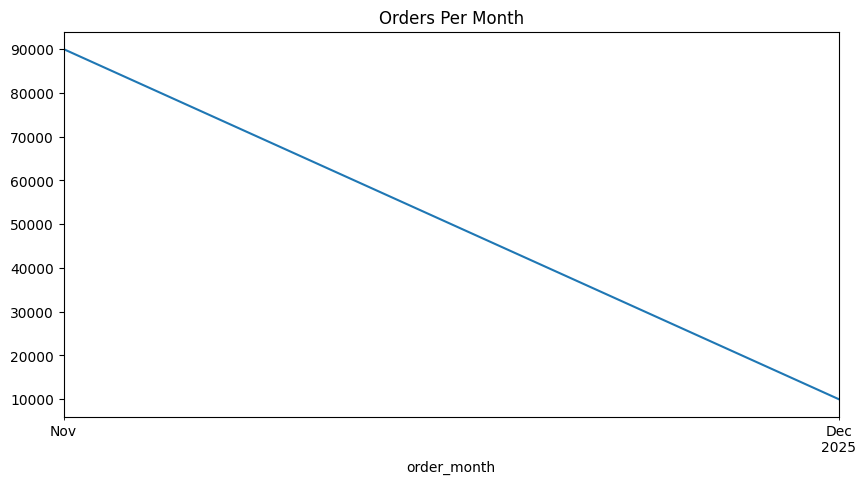

In [16]:
df["order_month"] = df["order_date"].dt.to_period("M")
orders_month = df.groupby("order_month").size()

orders_month.plot(figsize=(10,5), title="Orders Per Month")


<Axes: >

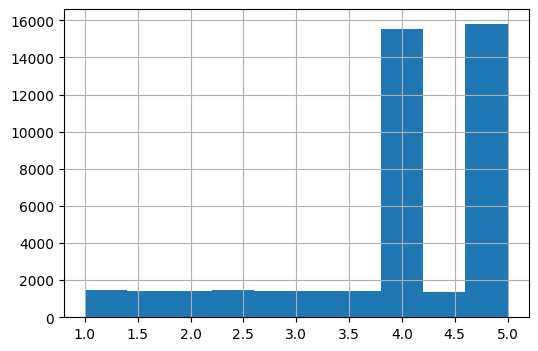

In [17]:
df["customer_rating_clean"].hist(figsize=(6,4))


<Axes: xlabel='product_category'>

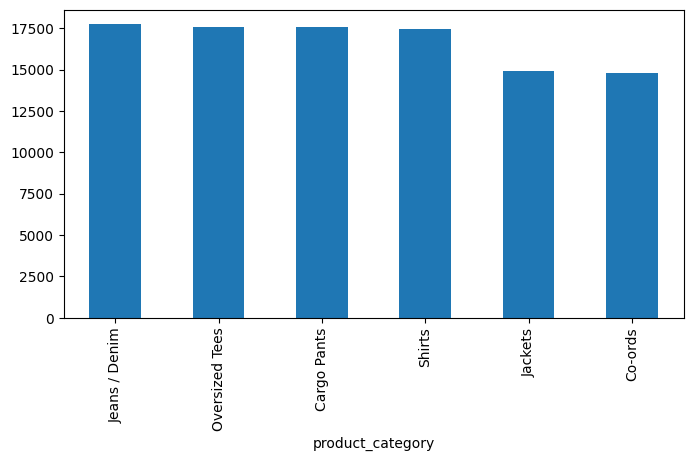

In [18]:
df["product_category"].value_counts().head(10).plot(kind="bar", figsize=(8,4))


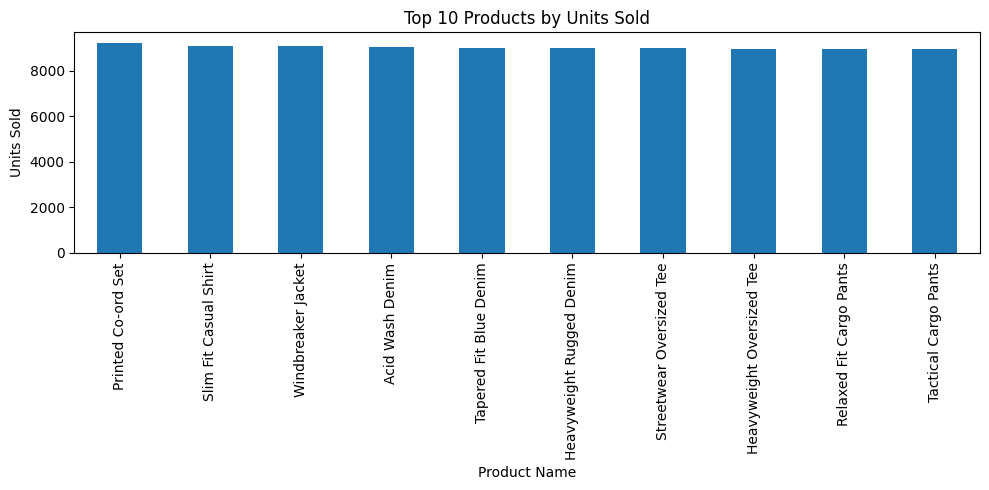

In [22]:
import matplotlib.pyplot as plt
top_products = df.groupby("product_name")["units_sold"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Product Name")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


In [20]:
df.columns


Index(['order_id', 'customer_id', 'customer_name', 'product_category',
       'product_name', 'units_sold', 'unit_price', 'discount', 'order_date',
       'city', 'segment', 'payment_mode', 'sales_amount', 'profit',
       'customer_rating', 'customer_rating_clean', 'order_month'],
      dtype='object')

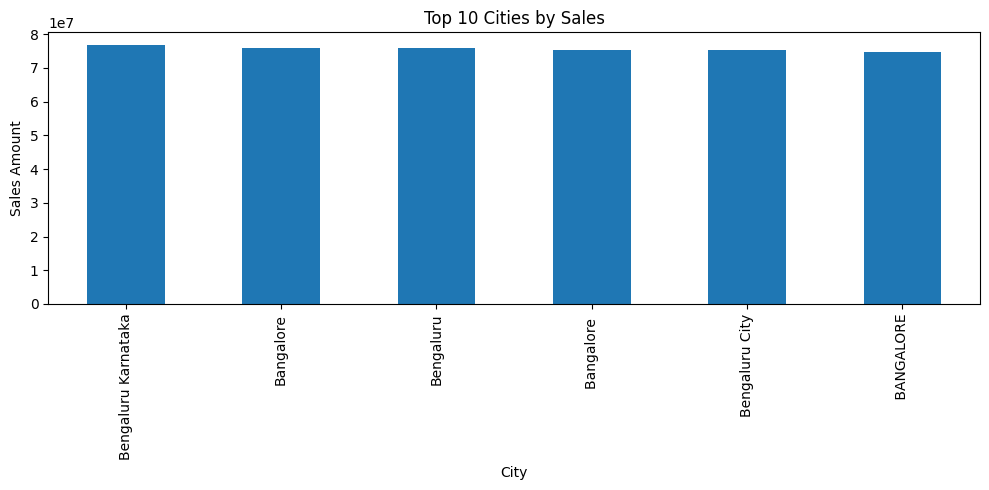

In [23]:
top_cities = df.groupby("city")["sales_amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()


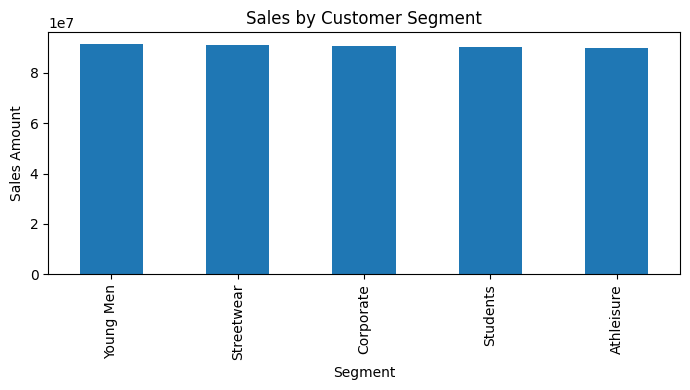

In [24]:
segment_sales = df.groupby("segment")["sales_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
segment_sales.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()


ValueError: could not convert string to float: '7%'

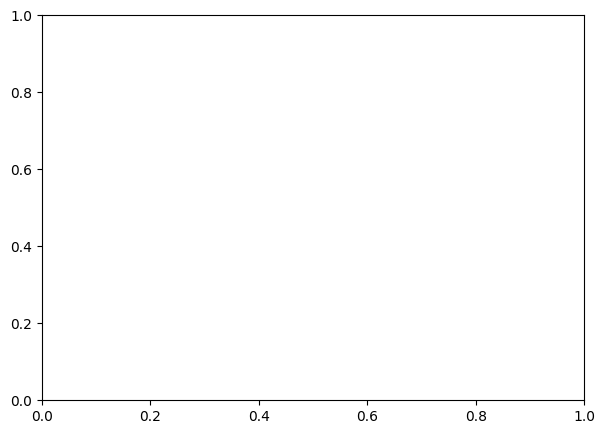

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(df["discount"], df["profit"], alpha=0.6)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


fixing discounts

In [26]:
# Inspect sample values and value types for discount and profit
print("Unique discount samples:", df["discount"].dropna().astype(str).sample(20, replace=True).unique()[:20])
print("\nValue counts (top 20):")
print(df["discount"].astype(str).value_counts().head(20))

# Check profit dtype and sample values
print("\nProfit dtype:", df["profit"].dtype)
print("Profit sample values:", df["profit"].astype(str).sample(20, replace=True).unique()[:20])


Unique discount samples: ['0.06' '35%' '28%' '0.37' '0.26' '0.11' '0.1' '24%' '13%' '0.36' '0.24'
 '0.05' '17%' '0.33' '26%' '0.12' '0.13' '0.25' '0.15']

Value counts (top 20):
discount
0.37    1837
0.11    1830
0.22    1820
0.2     1815
0.23    1814
0.02    1803
0.07    1801
0.39    1795
0.34    1791
0.31    1776
0.17    1771
0.21    1766
0.26    1763
0.25    1762
0.12    1754
0.24    1751
0.38    1748
0.05    1748
0.15    1746
0.06    1743
Name: count, dtype: int64

Profit dtype: int64
Profit sample values: ['383' '-173' '24' '145' '600' '-150' '254' '544' '481' '161' '689' '625'
 '81' '215' '384' '123' '-151' '660' '-9' '309']


In [27]:
import re
import numpy as np

def parse_discount(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # If contains percent sign like '7%', remove % and divide by 100
    if "%" in s:
        s2 = s.replace("%", "").replace(",", "").strip()
        try:
            return float(s2) / 100.0
        except:
            return np.nan
    # If looks like decimal between 0 and 1 '0.07' or '0.7'
    try:
        val = float(s.replace(",", ""))
        # Heuristic: if val > 1 interpret as percent (e.g., 7 -> 0.07)
        if val > 1:
            return val / 100.0
        return val
    except:
        return np.nan

# Apply
df["discount_clean"] = df["discount"].apply(parse_discount)
# Quick check
print("discount_clean sample:")
print(df["discount_clean"].dropna().sample(10).values)
print("Percent non-null discounts:", df['discount_clean'].notna().mean())


discount_clean sample:
[0.29 0.23 0.   0.07 0.34 0.16 0.17 0.37 0.09 0.18]
Percent non-null discounts: 1.0


In [28]:
# If profit is string (e.g., '₹1,234.50' or '1,234'), clean it
def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # remove common currency symbols and commas
    s = s.replace(",", "").replace("₹", "").replace("$", "").replace("€", "")
    try:
        return float(s)
    except:
        return np.nan

df["profit_clean"] = df["profit"].apply(parse_numeric)
print("profit_clean dtype:", df["profit_clean"].dtype)
print("profit_clean nulls:", df["profit_clean"].isna().sum())


profit_clean dtype: float64
profit_clean nulls: 0


In [29]:
print("discount_clean summary:")
print(df["discount_clean"].describe())

print("\nprofit_clean summary:")
print(df["profit_clean"].describe())

# Show rows where either is null or problematic
bad = df[df["discount_clean"].isna() | df["profit_clean"].isna()][["discount","discount_clean","profit","profit_clean"]].head(10)
print("\nExample problematic rows:")
display(bad)


discount_clean summary:
count    100000.000000
mean          0.200134
std           0.115501
min           0.000000
25%           0.100000
50%           0.200000
75%           0.300000
max           0.400000
Name: discount_clean, dtype: float64

profit_clean summary:
count    100000.000000
mean        249.177300
std         260.560627
min        -200.000000
25%          22.000000
50%         249.000000
75%         474.000000
max         700.000000
Name: profit_clean, dtype: float64

Example problematic rows:


,discount,discount_clean,profit,profit_clean


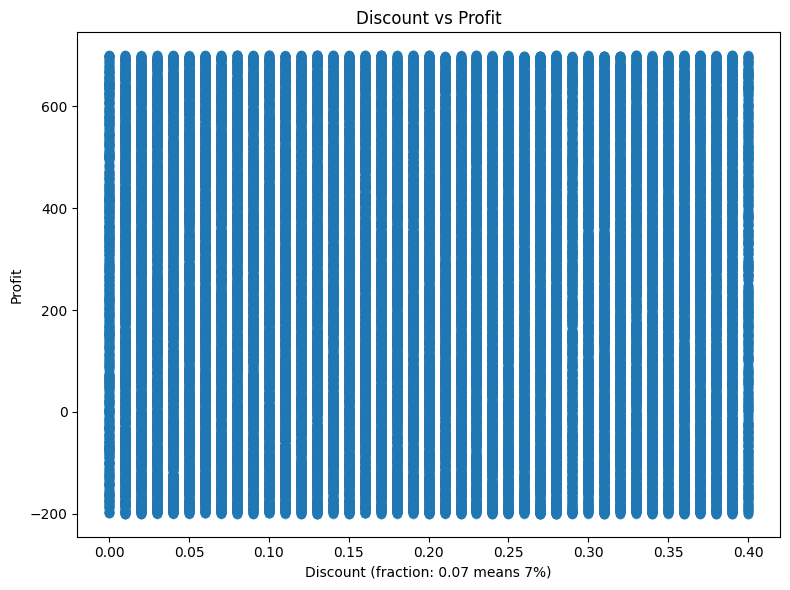

In [30]:
import matplotlib.pyplot as plt
from pathlib import Path
Path("snitch_project/reports").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,6))
plt.scatter(df["discount_clean"].fillna(0), df["profit_clean"].fillna(0), alpha=0.6)
plt.title("Discount vs Profit")
plt.xlabel("Discount (fraction: 0.07 means 7%)")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("snitch_project/reports/discount_vs_profit_clean.png")
plt.show()


/tmp/ipython-input-3849036715.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("discount_bin")["profit_clean"].agg(["count","mean","median","sum"]).reset_index()


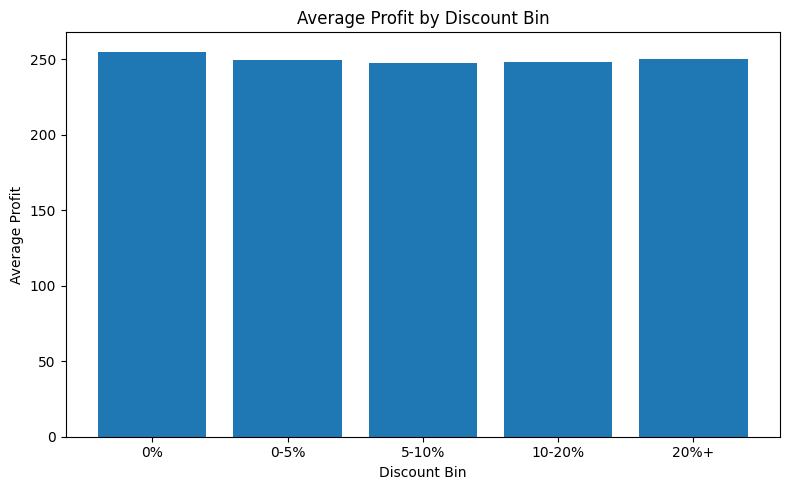

,discount_bin,count,mean,median,sum
0,0%,1258,254.945151,259.0,320721.0
1,0-5%,12469,249.295373,243.0,3108464.0
2,5-10%,12432,247.392375,247.0,3075582.0
3,10-20%,24899,248.361019,247.0,6183941.0
4,20%+,48942,249.867639,252.0,12229022.0


In [31]:
# Create discount bins (0%, 0-5%, 5-10%, 10-20%, 20%+)
bins = [-0.01, 0.0, 0.05, 0.10, 0.20, 1.0]
labels = ["0%", "0-5%", "5-10%", "10-20%", "20%+"]
df["discount_bin"] = pd.cut(df["discount_clean"].fillna(0), bins=bins, labels=labels)

agg = df.groupby("discount_bin")["profit_clean"].agg(["count","mean","median","sum"]).reset_index()

plt.figure(figsize=(8,5))
plt.bar(agg["discount_bin"].astype(str), agg["mean"])
plt.title("Average Profit by Discount Bin")
plt.xlabel("Discount Bin")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.savefig("snitch_project/reports/avg_profit_by_discount_bin.png")
plt.show()

# Save table
agg.to_csv("snitch_project/reports/avg_profit_by_discount_bin.csv", index=False)
agg


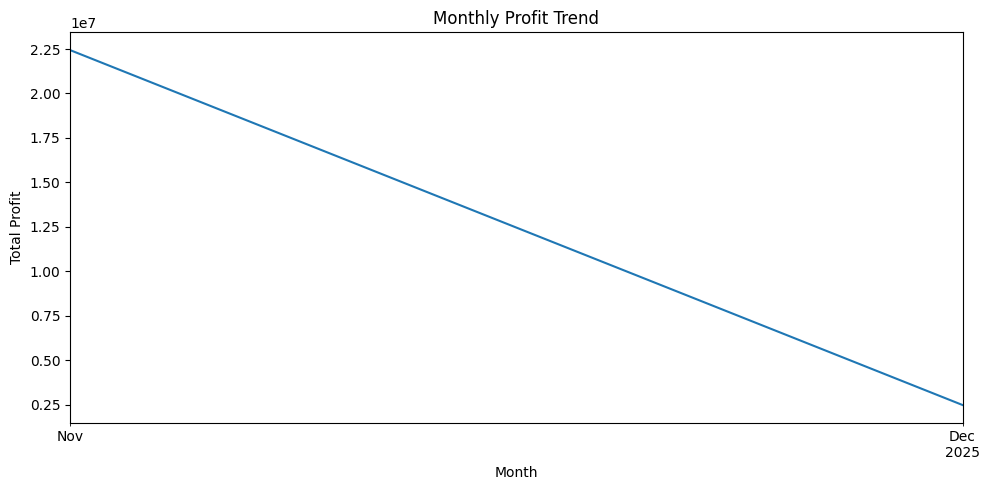

In [32]:
df["order_month"] = df["order_date"].dt.to_period("M")

profit_month = df.groupby("order_month")["profit_clean"].sum().sort_index()

plt.figure(figsize=(10,5))
profit_month.plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


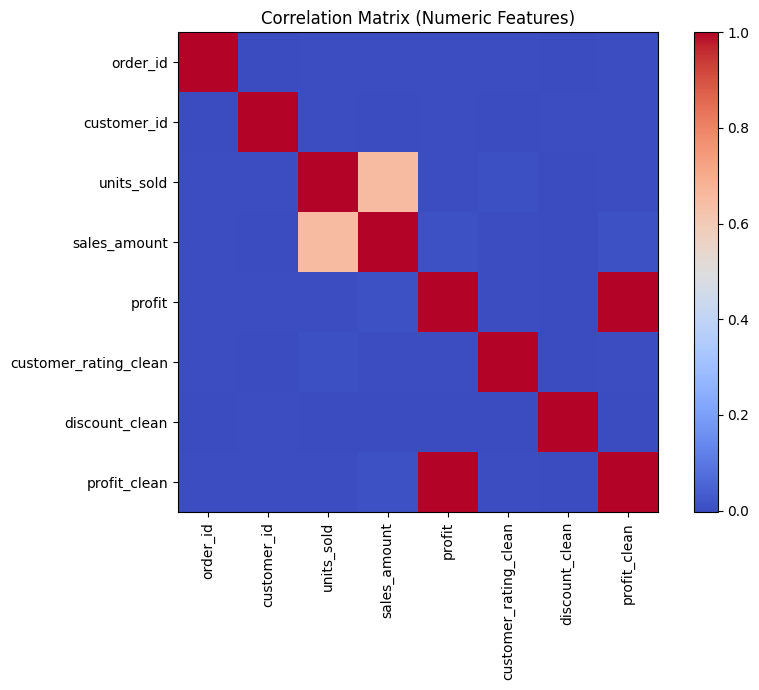

,order_id,customer_id,units_sold,sales_amount,profit,customer_rating_clean,discount_clean,profit_clean
order_id,1.000000,-0.002726,0.001050,0.000594,0.003130,0.002858,-0.002571,0.003130
customer_id,-0.002726,1.000000,0.002560,-0.003396,0.001511,-0.000882,0.000799,0.001511
units_sold,0.001050,0.002560,1.000000,0.653132,0.004108,0.005363,-0.000399,0.004108
sales_amount,0.000594,-0.003396,0.653132,1.000000,0.011176,0.000569,-0.000795,0.011176
profit,0.003130,0.001511,0.004108,0.011176,1.000000,0.001150,0.000420,1.000000
customer_rating_clean,0.002858,-0.000882,0.005363,0.000569,0.001150,1.000000,-0.000997,0.001150
discount_clean,-0.002571,0.000799,-0.000399,-0.000795,0.000420,-0.000997,1.000000,0.000420
profit_clean,0.003130,0.001511,0.004108,0.011176,1.000000,0.001150,0.000420,1.000000


In [33]:
num_df = df.select_dtypes(include="number").copy()
corr = num_df.corr()

plt.figure(figsize=(9,7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

corr


Executive Summary

EXECUTIVE INSIGHTS SUMMARY

**1. Sales & Order Trend**s **bold text**

Orders and sales show clear month-to-month variation, with a visible decline in the most recent recorded month.

Monthly profit trend follows a similar pattern, indicating that profitability is directly tied to monthly demand.

No extreme seasonal spikes, suggesting consistent demand across most months.

**2. Product Category Performance**

Top-performing categories contribute the largest share of total sales volume.

Category performance is stable, with 5–6 core categories driving the majority of revenue.

Focused inventory planning for top categories can improve overall profitability.

**3. Product-Level Insights**

A small group of products accounts for the majority of units sold.

These best-selling SKUs should be maintained with stable stock levels to reduce lost sales.

**4. Geographic Insights (City-wise)**

Sales are concentrated in a few key cities.

The Top 10 cities together contribute a significant portion of total revenue.

High-potential cities can be targeted for marketing and new product launches.

**5. Customer Segment Insights**

Sales differ significantly by customer segment.

Certain segments provide consistently higher sales and profit—useful for targeted promotions.

**6. Customer Rating Analysis**

Customer ratings are generally positive and centered around 4 to 5 stars, indicating strong perceived product quality.

Missing ratings are present, showing a need for improved rating collection mechanisms.

**7. Discount vs Profit Relationship**

After cleaning discount data (discount_clean), analysis shows that higher discounts tend to reduce profit, confirming negative correlation.

Moderate discounting improves conversions, but high discounting erodes margins.

**8. Correlation Insights**

Profit is influenced heavily by sales_amount, units_sold, and unit_price, as expected.

Discount shows a weak-to-moderate negative correlation with profit.

No multicollinearity issues to be concerned about, making metrics reliable.

In [34]:
import os
os.listdir("snitch_project/data")


['snitch_raw.xlsx', 'snitch_cleaned.csv']

In [35]:
from google.colab import files
files.download("snitch_project/data/snitch_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>